### Data quality and structure check

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

# Load dataset
df = pd.read_csv("/Users/yanlan/Downloads/df_train.csv")

# Convert date column and sort data
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

# First look
print("FIRST 5 ROWS")
print(df.head())
print("\nDATASET SHAPE")
print(df.shape)
print("\nCOLUMN NAMES")
print(df.columns.tolist())

# Basic dataset overview
print("\nBASIC OVERVIEW")
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])
print("Number of unique ETFs:", df["symbol"].nunique())
print("Number of unique dates:", df["date"].nunique())
print("Date range:", df["date"].min(), "to", df["date"].max())

# Missing values
print("\nMISSING VALUES BY COLUMN")
print(df.isna().sum())

# Duplicate rows
print("\nNUMBER OF DUPLICATE ROWS")
print(df.duplicated().sum())

# Observations per ETF
obs_per_symbol = df.groupby("symbol").size().sort_values()

print("\nOBSERVATIONS PER ETF - SUMMARY")
print(obs_per_symbol.describe())
print("\nETFs WITH FEWEST OBSERVATIONS")
print(obs_per_symbol.head())
print("\nETFs WITH MOST OBSERVATIONS")
print(obs_per_symbol.tail())

# ETFs per date
etfs_per_date = df.groupby("date")["symbol"].nunique()

print("\nETFs PER DATE - SUMMARY")
print(etfs_per_date.describe())
print("\nDATES WHERE NUMBER OF ETFs IS NOT 100")
print(etfs_per_date[etfs_per_date != 100])

# Summary statistics for raw variables
print("\nSUMMARY STATISTICS FOR RAW VARIABLES")
print(df[["open", "high", "low", "close", "volume"]].describe())

# Minimum values
print("\nMINIMUM VALUES")
print(df[["open", "high", "low", "close", "volume"]].min())

# Check for non-positive values
invalid_nonpositive = df[
    (df["open"] <= 0) |
    (df["high"] <= 0) |
    (df["low"] <= 0) |
    (df["close"] <= 0) |
    (df["volume"] <= 0)
]

print("\nNUMBER OF ROWS WITH NON-POSITIVE PRICE OR VOLUME")
print(len(invalid_nonpositive))

if len(invalid_nonpositive) > 0:
    print("\nEXAMPLES OF NON-POSITIVE ROWS")
    print(invalid_nonpositive.head())

# Check OHLC consistency
invalid_ohlc = df[
    (df["low"] > df["open"]) |
    (df["low"] > df["close"]) |
    (df["high"] < df["open"]) |
    (df["high"] < df["close"]) |
    (df["low"] > df["high"])
]

print("\nNUMBER OF ROWS WITH INVALID OHLC RELATIONSHIPS")
print(len(invalid_ohlc))

if len(invalid_ohlc) > 0:
    print("\nEXAMPLES OF INVALID OHLC ROWS")
    print(invalid_ohlc.head())

# Check uniqueness of (date, symbol)
pair_counts = df.groupby(["date", "symbol"]).size()

print("\nMAXIMUM ROWS FOR A SINGLE (DATE, SYMBOL) PAIR")
print(pair_counts.max())

duplicate_pairs = pair_counts[pair_counts > 1]
print("\nNUMBER OF DUPLICATED (DATE, SYMBOL) PAIRS")
print(len(duplicate_pairs))

if len(duplicate_pairs) > 0:
    print("\nEXAMPLES OF DUPLICATED (DATE, SYMBOL) PAIRS")
    print(duplicate_pairs.head())

# Data quality summary table
data_quality_summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Unique ETFs",
        "Unique dates",
        "Duplicate rows",
        "Rows with non-positive price/volume",
        "Rows with invalid OHLC logic",
        "Dates with ETF count != 100"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["symbol"].nunique(),
        df["date"].nunique(),
        df.duplicated().sum(),
        len(invalid_nonpositive),
        len(invalid_ohlc),
        (etfs_per_date != 100).sum()
    ]
})

print("\nDATA QUALITY SUMMARY")
print(data_quality_summary)

FIRST 5 ROWS
        date symbol   open  close    low   high     volume
0 2010-01-04   ACTS  15.13  14.97  14.84  15.28   5459.882
1 2010-01-05   ACTS  14.77  14.85  14.77  14.77   4023.304
2 2010-01-06   ACTS  14.62  14.86  14.62  14.62   5210.519
3 2010-01-07   ACTS  14.62  14.70  14.62  14.62   4070.668
4 2010-01-08   ACTS  14.38  14.40  14.38  14.38  31661.674

DATASET SHAPE
(100600, 7)

COLUMN NAMES
['date', 'symbol', 'open', 'close', 'low', 'high', 'volume']

BASIC OVERVIEW
Number of rows: 100600
Number of columns: 7
Number of unique ETFs: 100
Number of unique dates: 1006
Date range: 2010-01-04 00:00:00 to 2013-12-31 00:00:00

MISSING VALUES BY COLUMN
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64

NUMBER OF DUPLICATE ROWS
0

OBSERVATIONS PER ETF - SUMMARY
count     100.0
mean     1006.0
std         0.0
min      1006.0
25%      1006.0
50%      1006.0
75%      1006.0
max      1006.0
dtype: float64

ETFs WITH FEWEST OBSERVATIONS
sym

The dataset contains 100,600 observations across 100 ETFs and 1,006 trading dates from 2010-01-04 to 2013-12-31. There are no missing values, duplicate rows, or non-positive prices/volumes, and each date contains all 100 ETFs, indicating a balanced panel. However, many rows violate standard OHLC relationships, suggesting that the synthetic dataset does not fully follow real-market intraday price conventions. Therefore, while the dataset is structurally clean and suitable for modelling, features based on high and low prices should be interpreted with caution.

### Returns Analysis

SUMMARY STATISTICS FOR RETURNS
          simple_ret        log_ret
count  100500.000000  100500.000000
mean        0.000534       0.000209
std         0.025425       0.025499
min        -0.346491      -0.425399
25%        -0.011947      -0.012019
50%         0.000000       0.000000
75%         0.013100       0.013015
max         0.327778       0.283507

RETURN QUANTILES
       simple_ret   log_ret
0.001   -0.128205 -0.137201
0.010   -0.069074 -0.071575
0.050   -0.038718 -0.039488
0.950    0.039586  0.038822
0.990    0.071729  0.069273
0.999    0.123995  0.116889

ETF-LEVEL RETURN AND VOLATILITY STATS
        mean_simple_ret  std_simple_ret  mean_log_ret  std_log_ret
symbol                                                            
DLT            0.000849        0.046104     -0.000234     0.046937
QVG            0.000937        0.044693     -0.000076     0.045305
PJYC           0.001180        0.037668      0.000471     0.037689
LZK            0.000838        0.036277      0.000182    

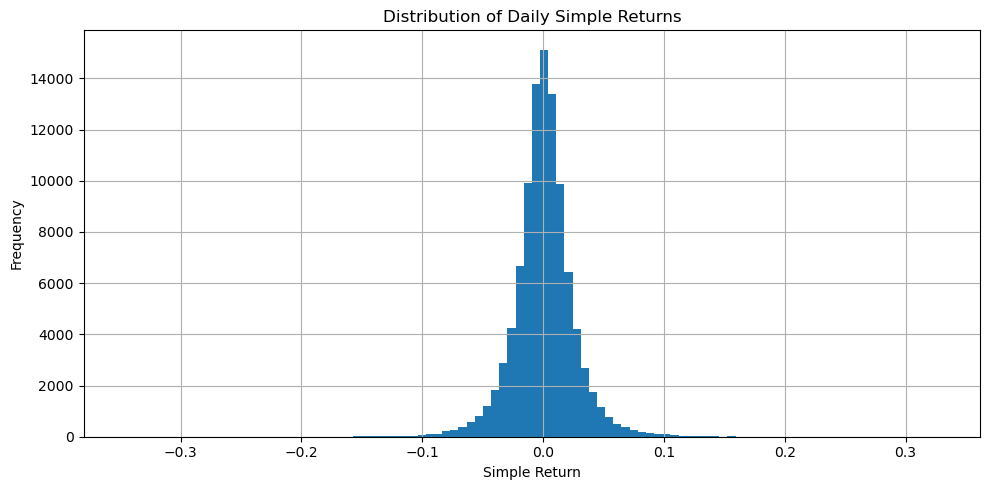

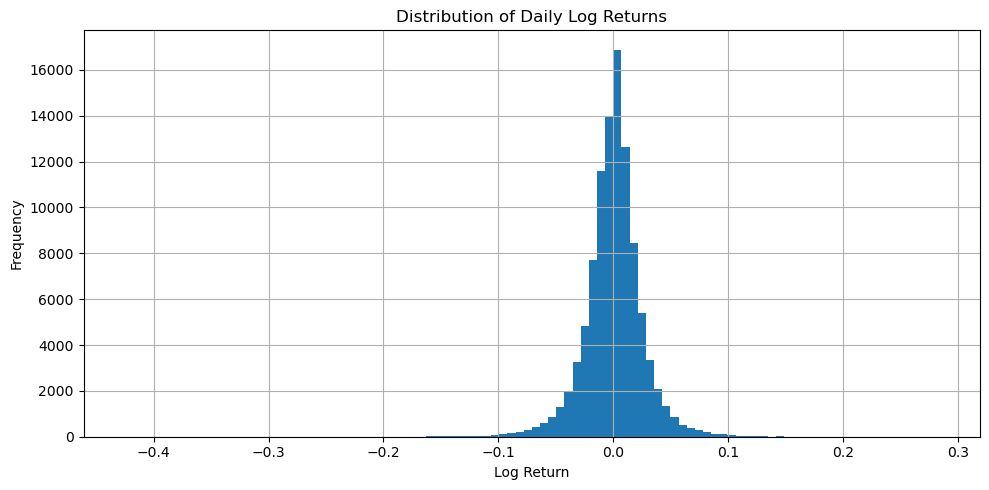

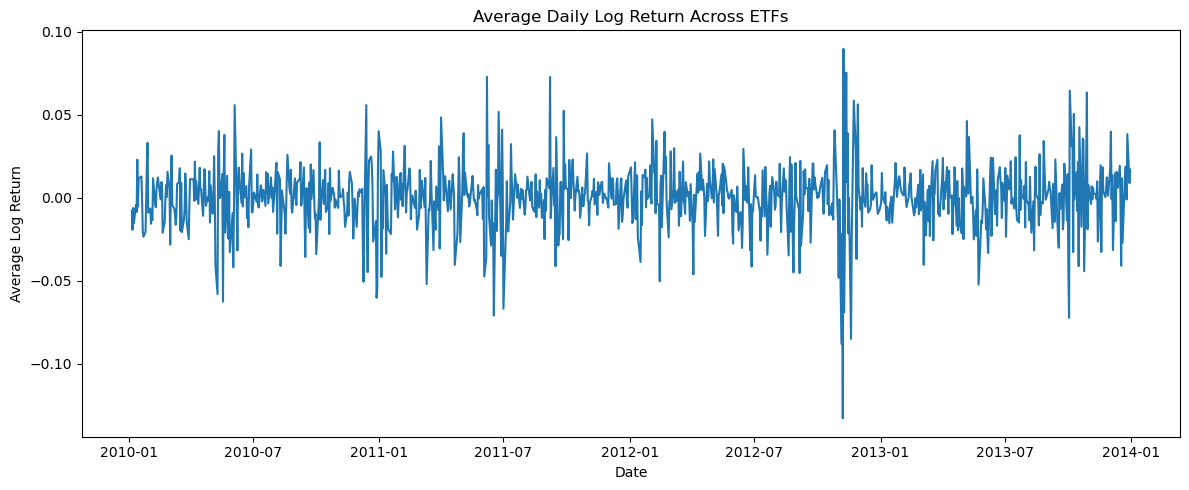

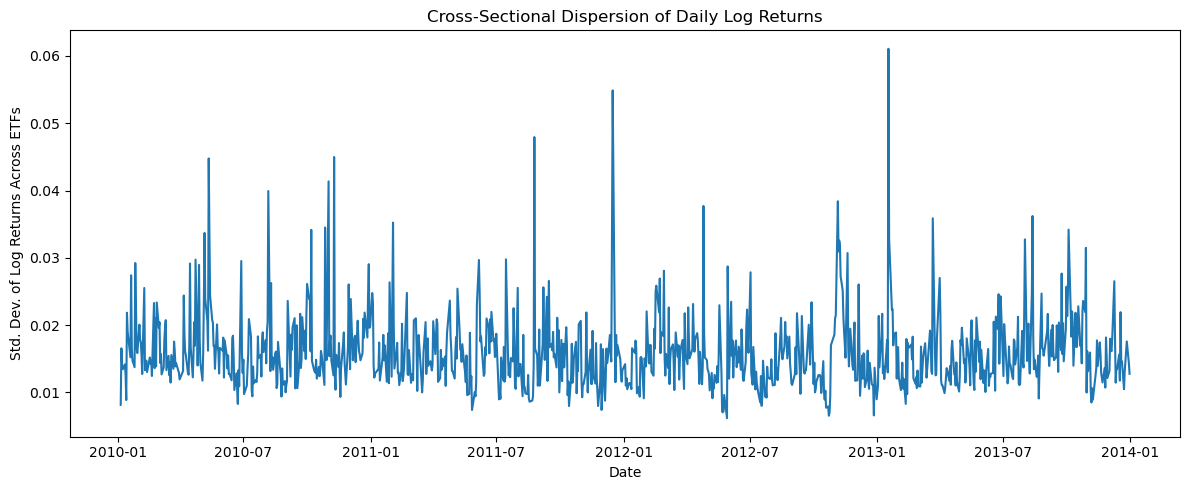

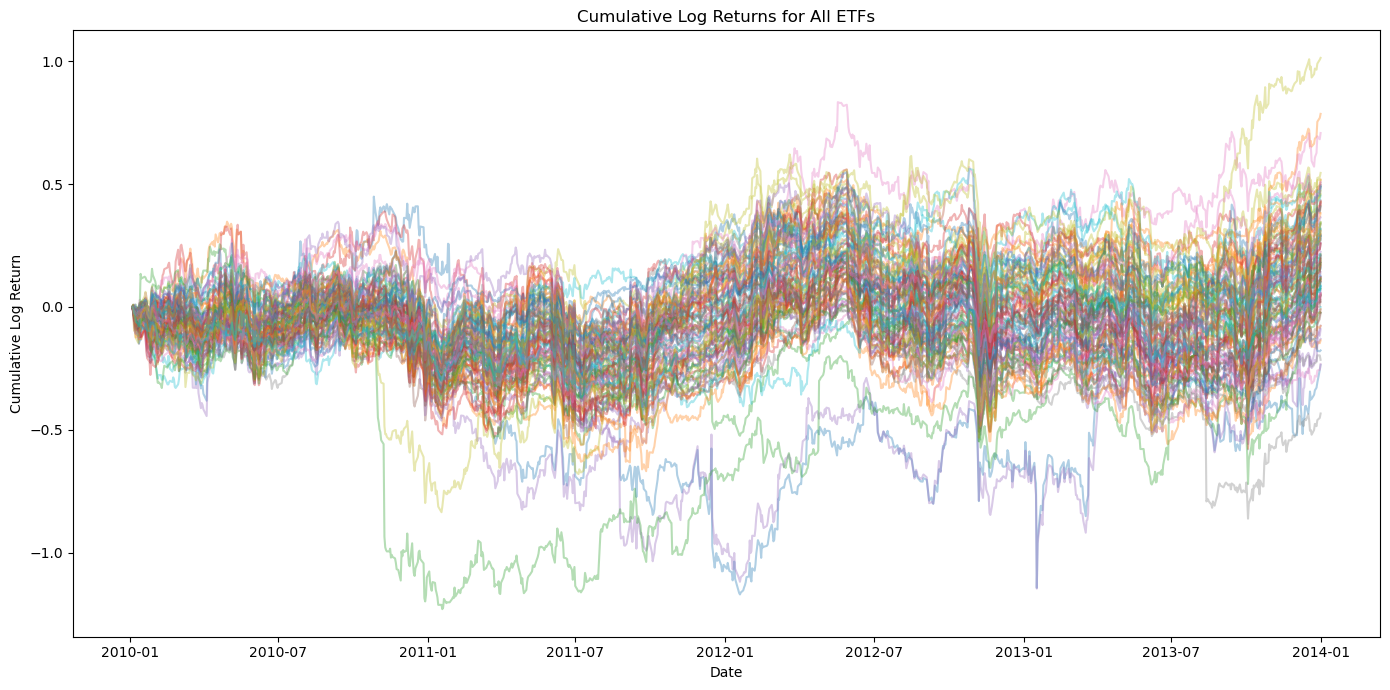

In [3]:
# Convert date column and sort data
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["symbol", "date"]).reset_index(drop=True)

# Create returns
df["simple_ret"] = df.groupby("symbol")["close"].pct_change()
df["log_ret"] = df.groupby("symbol")["close"].transform(lambda x: np.log(x / x.shift(1)))

# Summary statistics for returns
print("SUMMARY STATISTICS FOR RETURNS")
print(df[["simple_ret", "log_ret"]].describe())

# Check extreme returns
print("\nRETURN QUANTILES")
print(df[["simple_ret", "log_ret"]].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999]))

# Average return and volatility by ETF
etf_return_stats = df.groupby("symbol").agg(
    mean_simple_ret=("simple_ret", "mean"),
    std_simple_ret=("simple_ret", "std"),
    mean_log_ret=("log_ret", "mean"),
    std_log_ret=("log_ret", "std")
).sort_values("std_log_ret", ascending=False)

print("\nETF-LEVEL RETURN AND VOLATILITY STATS")
print(etf_return_stats.head(10))

# Cross-sectional average return by date
daily_avg_ret = df.groupby("date")["log_ret"].mean()

print("\nCROSS-SECTIONAL DAILY LOG RETURN SUMMARY")
print(daily_avg_ret.describe())

# Cross-sectional dispersion by date
daily_dispersion = df.groupby("date")["log_ret"].std()

print("\nCROSS-SECTIONAL DISPERSION OF LOG RETURNS")
print(daily_dispersion.describe())

# Plot distribution of simple returns
plt.figure(figsize=(10, 5))
df["simple_ret"].dropna().hist(bins=100)
plt.title("Distribution of Daily Simple Returns")
plt.xlabel("Simple Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot distribution of log returns
plt.figure(figsize=(10, 5))
df["log_ret"].dropna().hist(bins=100)
plt.title("Distribution of Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Plot cross-sectional average log return over time
plt.figure(figsize=(12, 5))
plt.plot(daily_avg_ret.index, daily_avg_ret.values)
plt.title("Average Daily Log Return Across ETFs")
plt.xlabel("Date")
plt.ylabel("Average Log Return")
plt.tight_layout()
plt.show()

# Plot cross-sectional dispersion over time
plt.figure(figsize=(12, 5))
plt.plot(daily_dispersion.index, daily_dispersion.values)
plt.title("Cross-Sectional Dispersion of Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Std. Dev. of Log Returns Across ETFs")
plt.tight_layout()
plt.show()

# Plot cumulative log returns for all ETFs
plt.figure(figsize=(14, 7))

for sym, temp in df.groupby("symbol"):
    temp = temp.copy()
    temp["cum_log_ret"] = temp["log_ret"].fillna(0).cumsum()
    plt.plot(temp["date"], temp["cum_log_ret"], alpha=0.35)

plt.title("Cumulative Log Returns for All ETFs")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")
plt.tight_layout()
plt.show()

Daily simple and log returns are centred close to zero, with small positive mean returns on average. The return distributions are sharply peaked with fat tails, indicating that while most daily moves are modest, occasional large positive and negative returns occur. Cross-sectional dispersion across ETFs is consistently present and spikes on certain dates, suggesting meaningful variation in relative performance that may support ranking-based strategies. The cumulative log return plot also shows substantial divergence across ETFs over time, indicating heterogeneous behaviour across assets. Overall, the return analysis suggests that the dataset contains sufficient cross-sectional and time-series variation for predictive signal testing, although the heavy tails imply that robustness and risk control will be important in strategy design.

### Feature Engineering

In [4]:
# Group by ETF
g = df.groupby("symbol")

# 1-day simple return
df["ret_1d"] = g["close"].pct_change()

# 1-day log return
df["log_ret"] = g["close"].transform(lambda x: np.log(x / x.shift(1)))

# Previous close
df["prev_close"] = g["close"].shift(1)

# Overnight return: today's open relative to yesterday's close
df["overnight_ret"] = df["open"] / df["prev_close"] - 1

# Intraday return: today's close relative to today's open
df["intraday_ret"] = df["close"] / df["open"] - 1

# High-low range scaled by open
df["hl_range"] = (df["high"] - df["low"]) / df["open"]

# Volume features
df["vol_chg"] = g["volume"].pct_change()
df["log_volume"] = np.log(df["volume"])

# Rolling average volume
df["avg_volume_5"] = g["volume"].transform(lambda x: x.rolling(5).mean())
df["avg_volume_20"] = g["volume"].transform(lambda x: x.rolling(20).mean())

# Relative volume
df["rel_volume_5"] = df["volume"] / df["avg_volume_5"]
df["rel_volume_20"] = df["volume"] / df["avg_volume_20"]

# Momentum features
df["mom_3"] = g["close"].pct_change(3)
df["mom_5"] = g["close"].pct_change(5)
df["mom_10"] = g["close"].pct_change(10)
df["mom_20"] = g["close"].pct_change(20)

# Rolling return means
df["ret_mean_5"] = g["ret_1d"].transform(lambda x: x.rolling(5).mean())
df["ret_mean_10"] = g["ret_1d"].transform(lambda x: x.rolling(10).mean())
df["ret_mean_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).mean())

# Rolling volatility
df["vol_5"] = g["ret_1d"].transform(lambda x: x.rolling(5).std())
df["vol_10"] = g["ret_1d"].transform(lambda x: x.rolling(10).std())
df["vol_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).std())

# Moving averages
df["ma_5"] = g["close"].transform(lambda x: x.rolling(5).mean())
df["ma_10"] = g["close"].transform(lambda x: x.rolling(10).mean())
df["ma_20"] = g["close"].transform(lambda x: x.rolling(20).mean())

# Price relative to moving averages
df["close_to_ma5"] = df["close"] / df["ma_5"] - 1
df["close_to_ma10"] = df["close"] / df["ma_10"] - 1
df["close_to_ma20"] = df["close"] / df["ma_20"] - 1

# Next-day return target
df["next_ret"] = g["close"].shift(-1) / df["close"] - 1

# Next-day log return target
df["next_log_ret"] = np.log(g["close"].shift(-1) / df["close"])

# Check missing values in engineered features
feature_cols = [
    "ret_1d", "log_ret", "overnight_ret", "intraday_ret", "hl_range",
    "vol_chg", "log_volume", "rel_volume_5", "rel_volume_20",
    "mom_3", "mom_5", "mom_10", "mom_20",
    "ret_mean_5", "ret_mean_10", "ret_mean_20",
    "vol_5", "vol_10", "vol_20",
    "close_to_ma5", "close_to_ma10", "close_to_ma20",
    "next_ret", "next_log_ret"
]

print("MISSING VALUES IN ENGINEERED FEATURES")
print(df[feature_cols].isna().sum())

# Summary statistics for engineered features
print("\nSUMMARY STATISTICS FOR ENGINEERED FEATURES")
print(df[feature_cols].describe())

# Preview engineered dataset
print("\nFIRST 10 ROWS OF ENGINEERED DATA")
print(df[["date", "symbol"] + feature_cols].head(10))

# Save engineered data if needed
# df.to_csv("/Users/yanlan/Downloads/df_train_engineered.csv", index=False)

MISSING VALUES IN ENGINEERED FEATURES
ret_1d            100
log_ret           100
overnight_ret     100
intraday_ret        0
hl_range            0
vol_chg           100
log_volume          0
rel_volume_5      400
rel_volume_20    1900
mom_3             300
mom_5             500
mom_10           1000
mom_20           2000
ret_mean_5        500
ret_mean_10      1000
ret_mean_20      2000
vol_5             500
vol_10           1000
vol_20           2000
close_to_ma5      400
close_to_ma10     900
close_to_ma20    1900
next_ret          100
next_log_ret      100
dtype: int64

SUMMARY STATISTICS FOR ENGINEERED FEATURES
              ret_1d        log_ret  overnight_ret   intraday_ret       hl_range        vol_chg     log_volume   rel_volume_5  \
count  100500.000000  100500.000000  100500.000000  100600.000000  100600.000000  100500.000000  100600.000000  100200.000000   
mean        0.000534       0.000209       0.000252       0.000641       0.000025       0.082748      10.383882       1.

The engineered features produced missing values only where expected from lagged and rolling-window calculations. For example, one-day return-based features are unavailable for the first observation of each ETF, momentum and rolling-volatility measures are unavailable for the first few observations depending on the window length, and next-day return targets are unavailable for the final observation of each ETF. This confirms that the feature engineering process behaved as intended and did not introduce unexpected missingness.

### Signal Analysis

CORRELATION OF SIGNALS WITH NEXT-DAY RETURN
           signal  corr_with_next_ret  abs_corr   n_obs
13     ret_mean_5           -0.051876  0.051876  100000
9           mom_3           -0.050791  0.050791  100200
10          mom_5           -0.050674  0.050674  100000
1         log_ret           -0.045639  0.045639  100400
0          ret_1d           -0.044812  0.044812  100400
20  close_to_ma10           -0.044544  0.044544   99600
2   overnight_ret           -0.043726  0.043726  100400
19   close_to_ma5           -0.043696  0.043696  100100
15    ret_mean_20           -0.038457  0.038457   98500
12         mom_20           -0.036688  0.036688   98500
21  close_to_ma20           -0.029016  0.029016   98600
18         vol_20            0.027182  0.027182   98500
16          vol_5            0.021005  0.021005  100000
5         vol_chg           -0.013705  0.013705  100400
3    intraday_ret            0.012603  0.012603  100500
4        hl_range           -0.009593  0.009593  100500
14  

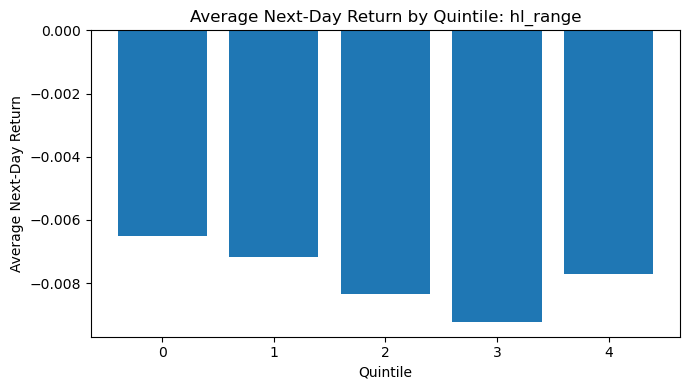

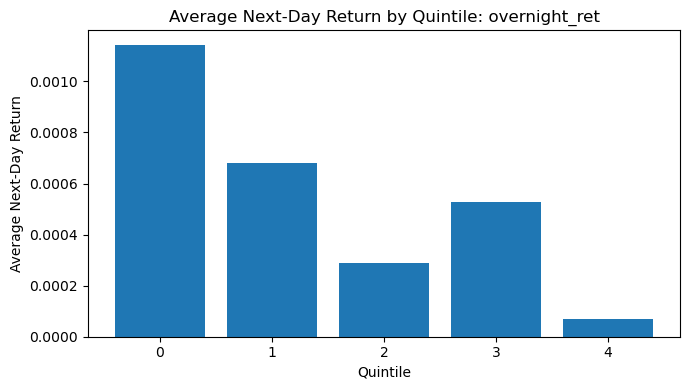

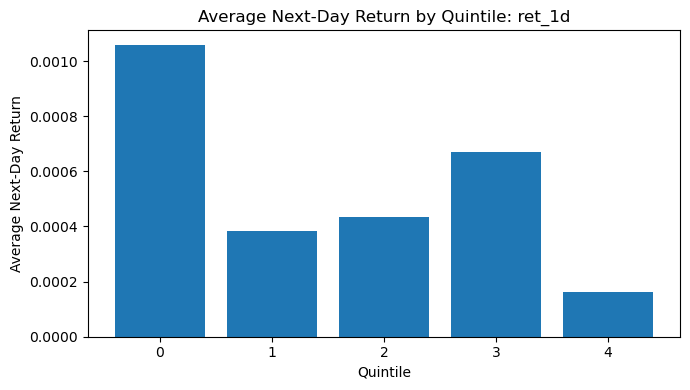

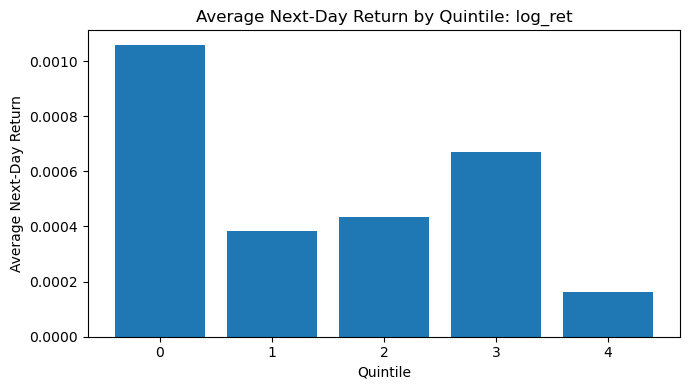

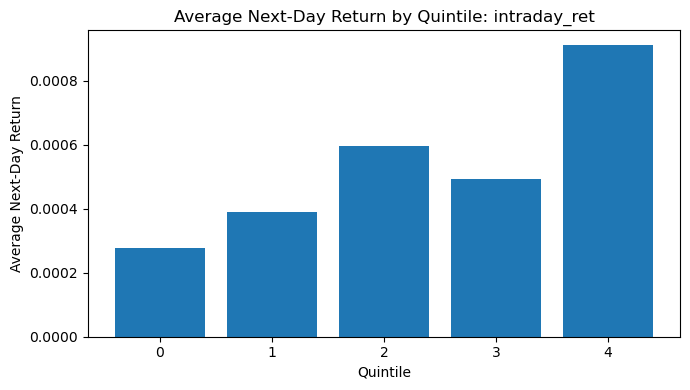

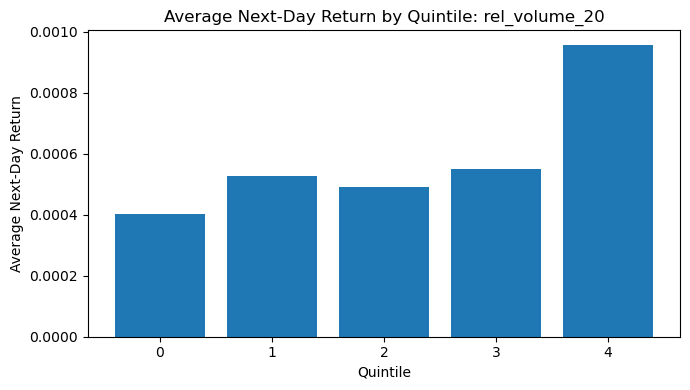

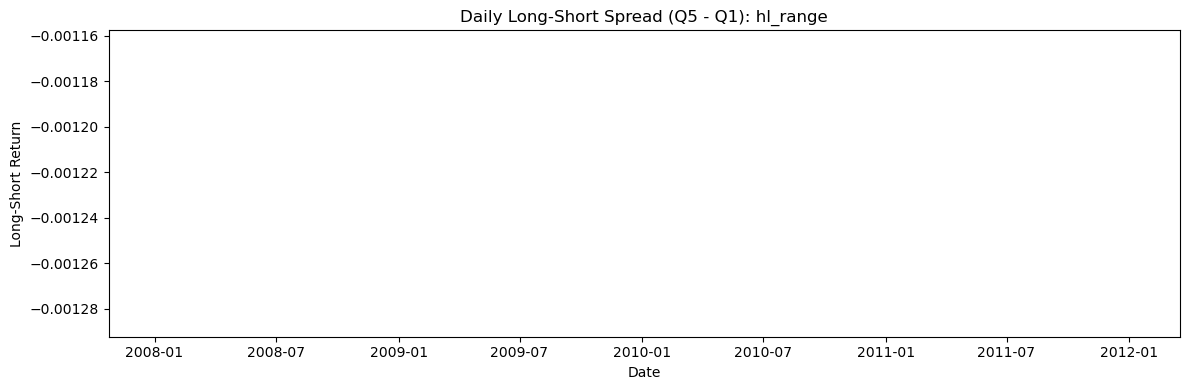

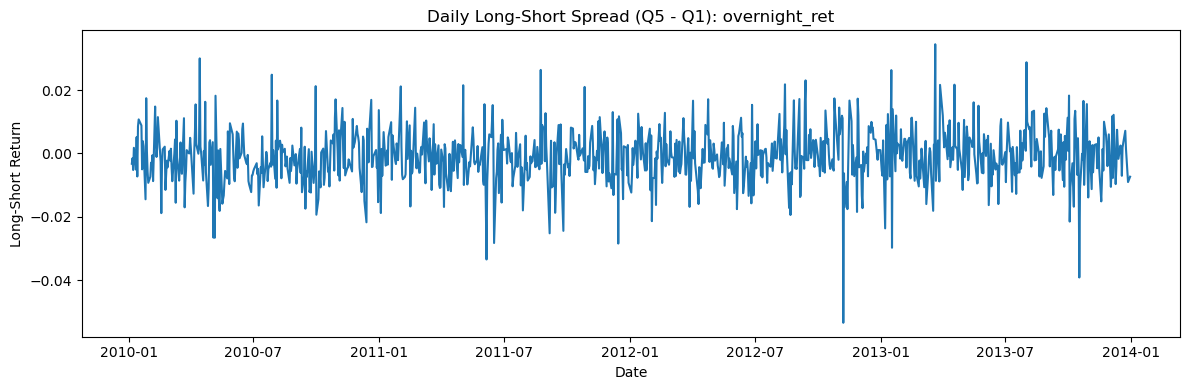

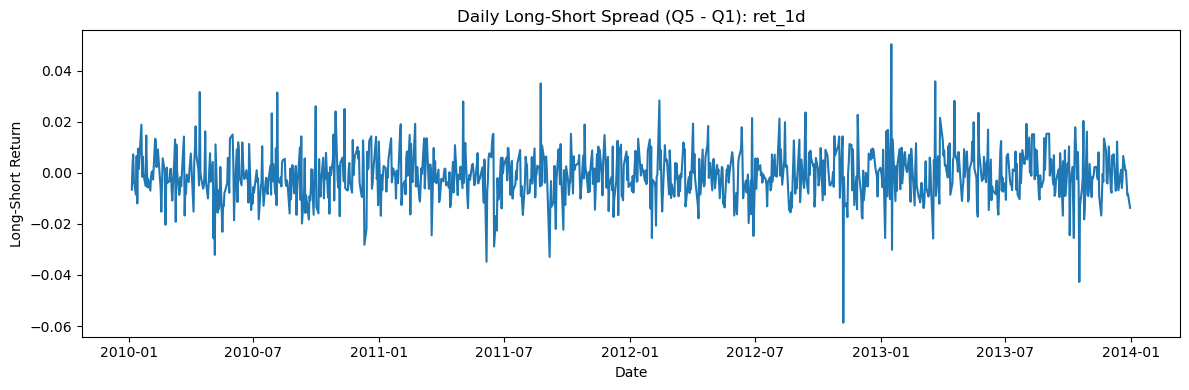


TOP 10 CANDIDATE SIGNALS
           signal   Q1_mean   Q5_mean  Q5_minus_Q1  abs_spread  monotonic
4        hl_range -0.006494 -0.007719    -0.001225    0.001225      False
2   overnight_ret  0.001143  0.000070    -0.001073    0.001073      False
0          ret_1d  0.001058  0.000164    -0.000895    0.000895      False
1         log_ret  0.001058  0.000164    -0.000895    0.000895      False
3    intraday_ret  0.000279  0.000913     0.000634    0.000634      False
8   rel_volume_20  0.000404  0.000956     0.000553    0.000553      False
14    ret_mean_10  0.000319  0.000854     0.000536    0.000536      False
11         mom_10  0.000370  0.000893     0.000523    0.000523      False
18         vol_20  0.000323  0.000791     0.000469    0.000469      False
17         vol_10  0.000358  0.000798     0.000439    0.000439      False


In [5]:
# Re-create engineered features
df["ret_1d"] = g["close"].pct_change()
df["log_ret"] = g["close"].transform(lambda x: np.log(x / x.shift(1)))
df["prev_close"] = g["close"].shift(1)
df["overnight_ret"] = df["open"] / df["prev_close"] - 1
df["intraday_ret"] = df["close"] / df["open"] - 1
df["hl_range"] = (df["high"] - df["low"]) / df["open"]
df["vol_chg"] = g["volume"].pct_change()
df["log_volume"] = np.log(df["volume"])
df["avg_volume_5"] = g["volume"].transform(lambda x: x.rolling(5).mean())
df["avg_volume_20"] = g["volume"].transform(lambda x: x.rolling(20).mean())
df["rel_volume_5"] = df["volume"] / df["avg_volume_5"]
df["rel_volume_20"] = df["volume"] / df["avg_volume_20"]
df["mom_3"] = g["close"].pct_change(3)
df["mom_5"] = g["close"].pct_change(5)
df["mom_10"] = g["close"].pct_change(10)
df["mom_20"] = g["close"].pct_change(20)
df["ret_mean_5"] = g["ret_1d"].transform(lambda x: x.rolling(5).mean())
df["ret_mean_10"] = g["ret_1d"].transform(lambda x: x.rolling(10).mean())
df["ret_mean_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).mean())
df["vol_5"] = g["ret_1d"].transform(lambda x: x.rolling(5).std())
df["vol_10"] = g["ret_1d"].transform(lambda x: x.rolling(10).std())
df["vol_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).std())
df["ma_5"] = g["close"].transform(lambda x: x.rolling(5).mean())
df["ma_10"] = g["close"].transform(lambda x: x.rolling(10).mean())
df["ma_20"] = g["close"].transform(lambda x: x.rolling(20).mean())
df["close_to_ma5"] = df["close"] / df["ma_5"] - 1
df["close_to_ma10"] = df["close"] / df["ma_10"] - 1
df["close_to_ma20"] = df["close"] / df["ma_20"] - 1
df["next_ret"] = g["close"].shift(-1) / df["close"] - 1
df["next_log_ret"] = np.log(g["close"].shift(-1) / df["close"])

# Candidate signals
signal_cols = [
    "ret_1d", "log_ret", "overnight_ret", "intraday_ret", "hl_range",
    "vol_chg", "log_volume", "rel_volume_5", "rel_volume_20",
    "mom_3", "mom_5", "mom_10", "mom_20",
    "ret_mean_5", "ret_mean_10", "ret_mean_20",
    "vol_5", "vol_10", "vol_20",
    "close_to_ma5", "close_to_ma10", "close_to_ma20"
]

# 1. Correlation of each feature with next-day return
corr_results = []

for col in signal_cols:
    temp = df[[col, "next_ret"]].dropna()
    corr = temp[col].corr(temp["next_ret"])
    corr_results.append({
        "signal": col,
        "corr_with_next_ret": corr,
        "abs_corr": abs(corr),
        "n_obs": len(temp)
    })

corr_df = pd.DataFrame(corr_results).sort_values("abs_corr", ascending=False)

print("CORRELATION OF SIGNALS WITH NEXT-DAY RETURN")
print(corr_df)

# 2. Quintile sort analysis for each signal
quintile_summary = []

for signal in signal_cols:
    temp = df[["date", signal, "next_ret"]].dropna().copy()
    
    # Assign quintiles within each date
    temp["quintile"] = temp.groupby("date")[signal].transform(
        lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop")
    )
    
    # Drop dates where qcut failed to produce full quintiles
    temp = temp.dropna(subset=["quintile"])
    temp["quintile"] = temp["quintile"].astype(int)
    
    avg_by_quintile = temp.groupby("quintile")["next_ret"].mean()
    
    if len(avg_by_quintile) == 5:
        spread = avg_by_quintile.loc[4] - avg_by_quintile.loc[0]
        monotonic = avg_by_quintile.is_monotonic_increasing or avg_by_quintile.is_monotonic_decreasing
        
        quintile_summary.append({
            "signal": signal,
            "Q1_mean": avg_by_quintile.loc[0],
            "Q2_mean": avg_by_quintile.loc[1],
            "Q3_mean": avg_by_quintile.loc[2],
            "Q4_mean": avg_by_quintile.loc[3],
            "Q5_mean": avg_by_quintile.loc[4],
            "Q5_minus_Q1": spread,
            "abs_spread": abs(spread),
            "monotonic": monotonic
        })

quintile_df = pd.DataFrame(quintile_summary).sort_values("abs_spread", ascending=False)

print("\nQUINTILE ANALYSIS OF SIGNALS")
print(quintile_df)

# 3. Plot top 6 signals by absolute quintile spread
top_signals = quintile_df.head(6)["signal"].tolist()

for signal in top_signals:
    temp = df[["date", signal, "next_ret"]].dropna().copy()
    temp["quintile"] = temp.groupby("date")[signal].transform(
        lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop")
    )
    temp = temp.dropna(subset=["quintile"])
    temp["quintile"] = temp["quintile"].astype(int)
    
    avg_by_quintile = temp.groupby("quintile")["next_ret"].mean()
    
    plt.figure(figsize=(7, 4))
    plt.bar(avg_by_quintile.index.astype(str), avg_by_quintile.values)
    plt.title(f"Average Next-Day Return by Quintile: {signal}")
    plt.xlabel("Quintile")
    plt.ylabel("Average Next-Day Return")
    plt.tight_layout()
    plt.show()

# 4. Time-series of long-short spread for top 3 signals
top_3_signals = quintile_df.head(3)["signal"].tolist()

for signal in top_3_signals:
    temp = df[["date", signal, "next_ret"]].dropna().copy()
    temp["quintile"] = temp.groupby("date")[signal].transform(
        lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop")
    )
    temp = temp.dropna(subset=["quintile"])
    temp["quintile"] = temp["quintile"].astype(int)
    
    daily_q_returns = temp.groupby(["date", "quintile"])["next_ret"].mean().unstack()
    
    if set([0, 4]).issubset(daily_q_returns.columns):
        daily_q_returns["long_short"] = daily_q_returns[4] - daily_q_returns[0]
        
        plt.figure(figsize=(12, 4))
        plt.plot(daily_q_returns.index, daily_q_returns["long_short"])
        plt.title(f"Daily Long-Short Spread (Q5 - Q1): {signal}")
        plt.xlabel("Date")
        plt.ylabel("Long-Short Return")
        plt.tight_layout()
        plt.show()

# 5. Summary of top candidate signals
top_candidates = quintile_df[[
    "signal", "Q1_mean", "Q5_mean", "Q5_minus_Q1", "abs_spread", "monotonic"
]].head(10)

print("\nTOP 10 CANDIDATE SIGNALS")
print(top_candidates)

####  Main takeaways from the signal discovery analysis

##### 1. The strongest signals are mostly reversal-type
From the correlation table, the largest absolute correlations with next_ret come from ret_mean_5, mom_3, mom_5, log_ret, ret_1d, close_to_ma10, overnight_ret.

Most of these have negative correlation with next-day return.

This suggests a short-term mean reversion effect:
* ETFs that performed strongly in the recent past tend to underperform the next day
* ETFs that performed poorly in the recent past tend to rebound the next day

So, at this stage, the injected signal looks more like reversal than momentum.

##### 2. Quintile plots support the reversal interpretation
The quintile analysis for the following signals: ret_1d, log_ret, overnight_ret.
This shows that:
* the lowest quintile often has the highest average next-day return - yesterday’s losers tend to outperform tomorrow.
* the highest quintile often has the lowest average next-day return - yesterday’s winners tend to underperform tomorrow.

This makes these variables strong candidates for a cross-sectional ranking strategy.

##### 3. intraday_ret behaves differently
Unlike the recent-return variables above, intraday_ret shows a positive relationship with next-day return: higher intraday return tends to be followed by higher next-day return. This suggests a mild continuation effect for intraday moves. So the signal may not be uniform across all definitions of return:
* close-to-close and recent return features appear mean-reverting
* intraday return appears to show some continuation
This is important because it suggests the final strategy may benefit from combining different types of features rather than relying on only one.

##### 4. hl_range looks strong, but should be treated cautiously
hl_range has the largest quintile spread in the results.However, this should be interpreted with caution because Section 1 showed that the dataset does not fully satisfy standard OHLC relationships. So while hl_range appears statistically strong, it may not be the best variable to place at the centre of the final trading rule.

A sensible approach would be:
* keep it as a possible supplementary feature
* avoid making it the main signal without further testing

##### 5. Volume-based variables look weaker but still potentially useful
Some volume-related variables, including: rel_volume_20, vol_20, vol_10. These show positive quintile spreads, but these are smaller than those from the main reversal signals. This suggests volume may contain some predictive information but it is likely to be secondary, rather than the main driver of returns

A possible use for these variables later would be:
* as filters
* as interaction terms
* as a way to strengthen or confirm a reversal signal

For example, you might later test whether reversal is stronger after unusually high volume.

##### Interpretation of the injected signal
Overall, the exploratory results suggest that the hidden predictive signal in the corrected dataset is most consistent with short-term reversal.
That means:
* recent losers tend to outperform on the next day
* recent winners tend to underperform on the next day

This pattern appears in: one-day return, log return, short-window momentum, short-window mean return, overnight return.

So the injected signal does not appear to be a broad trend-following effect. Instead, it looks like a cross-sectional mean-reversion signal.

This is useful because it naturally supports a trading strategy of the form:
* rank ETFs each day by a recent-return signal
* go long the weakest names
* go short or avoid the strongest names

##### Most promising signals at this stage

Primary candidates:
These appear to be the strongest and most interpretable signals so far: ret_1d, log_ret, overnight_ret, ret_mean_5, mom_3, mom_5.

Secondary Candidates:
These may still be useful, either on their own or in combination: intraday_ret, rel_volume_20, vol_10, vol_20.

Although it has strong apparent predictive power, it depends on high and low, which may be unreliable in this synthetic dataset due to the OHLC inconsistencies found earlier.

##### Why the daily long-short spread graphs look noisy
The daily long-short spread series for the top signals fluctuate around zero and look quite noisy. This is not a problem.
It simply means:
* the signal is weak on a day-to-day basis
* the predictive edge is small relative to daily market noise
* individual daily outcomes are volatile

What matters more is not whether the daily spread is smooth, but whether:
* the average spread is positive or negative in the expected direction
* the cumulative spread trends over time
* the strategy still works after transaction costs

So the noisy long-short graphs do not invalidate the signal. They just show that the effect is subtle and must be evaluated carefully.

##### Implications for strategy design
The most natural baseline strategy from this analysis is a cross-sectional mean-reversion strategy.
A simple version would be:
* on each date, rank ETFs by ret_1d or log_ret
* buy the ETFs in the bottom quintile or bottom decile
* sell, short, or avoid the ETFs in the top quintile or top decile
* rebalance daily
* keep position sizes conservative
* account for transaction costs

This strategy fits the evidence because: the weakest recent performers appear to have the highest next-day expected return and the strongest recent performers appear to have the lowest next-day expected return.

However, because the assignment penalises large losses and wealth collapse, the final implementation should probably include some risk controls such as:
* limiting the number of names traded
* capping exposure per ETF
* reducing turnover
* not allocating all wealth every day

##### Overall conclusion
The signal discovery analysis suggests that the corrected dataset contains a weak but meaningful short-term reversal effect.
The strongest evidence comes from recent-return based features, which consistently show that:
* recent winners underperform
* recent losers rebound

This makes reversal-based ranking signals the strongest candidates for the first baseline strategy.

Other features, such as intraday return and some volume-based variables, may still add value, but they appear secondary relative to the main reversal signal.

The next stage should therefore be to test a baseline backtest using one of the main reversal signals, such as ret_1d or log_ret, and evaluate whether the effect is still profitable once transaction costs are included.

### CROSS-SECTIONAL VS TIME-SERIES REVERSAL

CROSS-SECTIONAL QUINTILE MEANS
cs_quintile
0    0.001058
1    0.000382
2    0.000433
3    0.000671
4    0.000164
Name: next_ret, dtype: float64

CROSS-SECTIONAL Q5 - Q1 SPREAD
-0.0008946597798644644


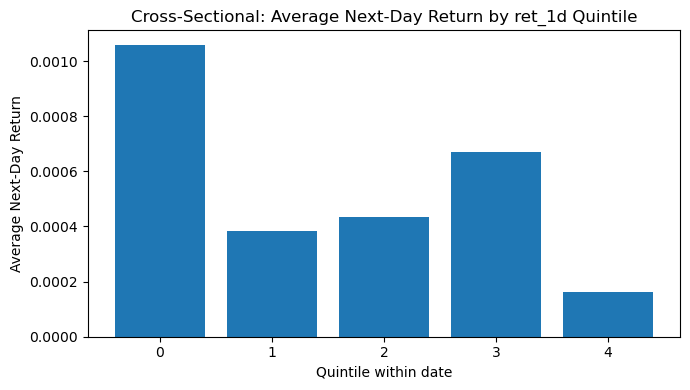

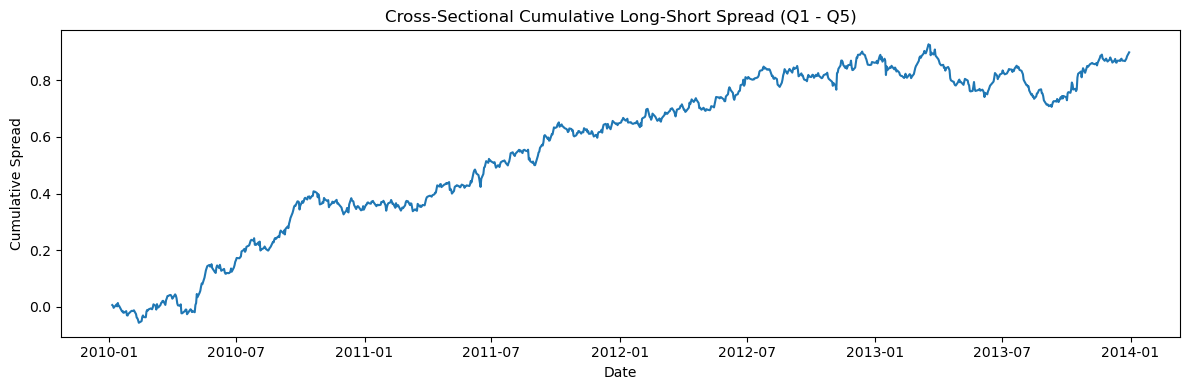


TIME-SERIES QUINTILE MEANS
ts_quintile
0    0.000740
1    0.000759
2    0.000722
3    0.000993
4   -0.000204
Name: next_ret, dtype: float64

TIME-SERIES Q5 - Q1 SPREAD
-0.0009437410680858281


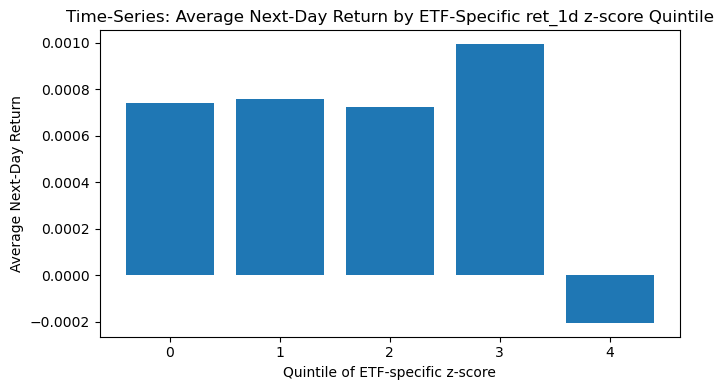


CROSS-SECTIONAL DE-MEANED QUINTILE MEANS
q
0    0.001058
1    0.000382
2    0.000433
3    0.000671
4    0.000164
Name: next_ret, dtype: float64

CROSS-SECTIONAL DE-MEANED Q1 - Q5 SPREAD
0.0008946597798644644


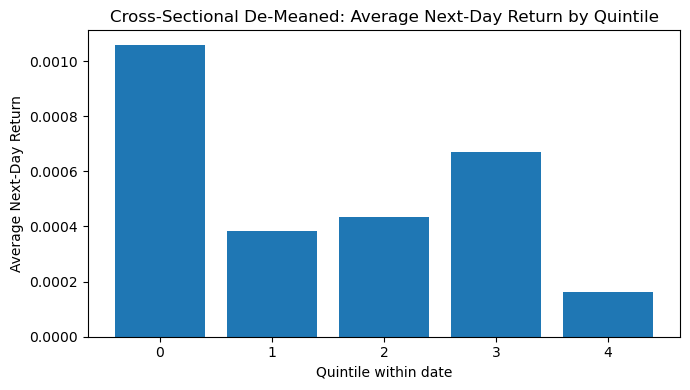

In [6]:
# --------------------------------------------------
# 1. CROSS-SECTIONAL MEAN-REVERSION
# --------------------------------------------------
# Rank ETFs within each date by today's return
cs = df[["date", "symbol", "ret_1d", "next_ret"]].dropna().copy()

cs["cs_quintile"] = cs.groupby("date")["ret_1d"].transform(
    lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop")
)

cs = cs.dropna(subset=["cs_quintile"])
cs["cs_quintile"] = cs["cs_quintile"].astype(int)

# Average next-day return by cross-sectional quintile
cs_quintile_mean = cs.groupby("cs_quintile")["next_ret"].mean()

print("CROSS-SECTIONAL QUINTILE MEANS")
print(cs_quintile_mean)

print("\nCROSS-SECTIONAL Q5 - Q1 SPREAD")
print(cs_quintile_mean.loc[4] - cs_quintile_mean.loc[0])

# Plot
plt.figure(figsize=(7, 4))
plt.bar(cs_quintile_mean.index.astype(str), cs_quintile_mean.values)
plt.title("Cross-Sectional: Average Next-Day Return by ret_1d Quintile")
plt.xlabel("Quintile within date")
plt.ylabel("Average Next-Day Return")
plt.tight_layout()
plt.show()

# Daily long-short spread
cs_daily = cs.groupby(["date", "cs_quintile"])["next_ret"].mean().unstack()
cs_daily = cs_daily[[0, 4]].dropna()
cs_daily["long_short"] = cs_daily[0] - cs_daily[4]   # losers minus winners
cs_daily["cum_long_short"] = cs_daily["long_short"].fillna(0).cumsum()

plt.figure(figsize=(12, 4))
plt.plot(cs_daily.index, cs_daily["cum_long_short"])
plt.title("Cross-Sectional Cumulative Long-Short Spread (Q1 - Q5)")
plt.xlabel("Date")
plt.ylabel("Cumulative Spread")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 2. TIME-SERIES MEAN-REVERSION
# --------------------------------------------------
# Standardise each ETF's return relative to its own history
df["ret_mean_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).mean())
df["ret_std_20"] = g["ret_1d"].transform(lambda x: x.rolling(20).std())

df["ts_zscore"] = (df["ret_1d"] - df["ret_mean_20"]) / df["ret_std_20"]

ts = df[["date", "symbol", "ts_zscore", "next_ret"]].dropna().copy()

# Bin each ETF-day observation by its own-history z-score
ts["ts_quintile"] = pd.qcut(ts["ts_zscore"], q=5, labels=False, duplicates="drop")
ts["ts_quintile"] = ts["ts_quintile"].astype(int)

# Average next-day return by time-series quintile
ts_quintile_mean = ts.groupby("ts_quintile")["next_ret"].mean()

print("\nTIME-SERIES QUINTILE MEANS")
print(ts_quintile_mean)

print("\nTIME-SERIES Q5 - Q1 SPREAD")
print(ts_quintile_mean.loc[4] - ts_quintile_mean.loc[0])

# Plot
plt.figure(figsize=(7, 4))
plt.bar(ts_quintile_mean.index.astype(str), ts_quintile_mean.values)
plt.title("Time-Series: Average Next-Day Return by ETF-Specific ret_1d z-score Quintile")
plt.xlabel("Quintile of ETF-specific z-score")
plt.ylabel("Average Next-Day Return")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# 3. CROSS-SECTIONAL DE-MEANED TEST
# --------------------------------------------------
# Remove the market-wide daily average return and see whether relative underperformance predicts reversal
df["cs_demeaned_ret"] = df["ret_1d"] - df.groupby("date")["ret_1d"].transform("mean")

cs_dm = df[["date", "symbol", "cs_demeaned_ret", "next_ret"]].dropna().copy()

cs_dm["q"] = cs_dm.groupby("date")["cs_demeaned_ret"].transform(
    lambda x: pd.qcut(x, q=5, labels=False, duplicates="drop")
)

cs_dm = cs_dm.dropna(subset=["q"])
cs_dm["q"] = cs_dm["q"].astype(int)

cs_dm_mean = cs_dm.groupby("q")["next_ret"].mean()

print("\nCROSS-SECTIONAL DE-MEANED QUINTILE MEANS")
print(cs_dm_mean)

print("\nCROSS-SECTIONAL DE-MEANED Q1 - Q5 SPREAD")
print(cs_dm_mean.loc[0] - cs_dm_mean.loc[4])

plt.figure(figsize=(7, 4))
plt.bar(cs_dm_mean.index.astype(str), cs_dm_mean.values)
plt.title("Cross-Sectional De-Meaned: Average Next-Day Return by Quintile")
plt.xlabel("Quintile within date")
plt.ylabel("Average Next-Day Return")
plt.tight_layout()
plt.show()

The additional tests show that the corrected dataset contains **both cross-sectional and time-series mean reversion**. ETFs that underperform relative to other ETFs on a given day tend to outperform on the following day, while ETFs with unusually strong returns relative to their own recent history also tend to reverse. The cross-sectional de-meaned results are almost unchanged, indicating that this effect is driven by **relative performance within the ETF universe rather than broad market movements**. Overall, the evidence suggests that **cross-sectional mean reversion is the most relevant and robust signal for strategy design**, making a daily loser-versus-winner ranking strategy a strong baseline candidat

# Recommended Trading Strategies

I’d test these four:
* Cross-sectional mean-reversion rule using ret_1d or log_ret
* Pooled linear regression - OLS & Ridge
* Gradient boosted trees
* ARMA / AR benchmark

#### <u> Cross-sectional mean-reversion rule using ret_1d or log_ret </u>
What it is:
- Rank all ETFs each day using a recent-return signal such as one-day simple return (ret_1d) or one-day log return (log_ret)
- Go long the lowest-ranked ETFs and short or avoid the highest-ranked ETFs
- Rebalance daily

Why it is suitable:
- The analysis found clear evidence of cross-sectional mean reversion
- ETFs that underperformed relative to other ETFs on the same day tended to outperform the next day
- The loser-minus-winner cumulative spread also increased over time
- The result remained after cross-sectionally demeaning returns, so the signal is not just driven by broad market moves

Strengths:
- Very simple and interpretable
- Directly aligned with the strongest signal found so far
- Easy to implement and fast to test
- Provides a strong baseline for comparing more complex models

Things to decide:
- Whether to rank by ret_1d or log_ret
- Whether to trade quintiles, deciles, or a fixed number of ETFs
- Whether to use a long-short or long-only version
- How to limit turnover and transaction costs

##### <u>Pooled linear regression — OLS and Ridge</u>
##### **OLS**
What it is:
- Use all ETF-date observations together in one pooled dataset
- Predict next-day return using multiple engineered predictors
Use predicted returns to rank ETFs and form positions

Why it is suitable:
- The analysis suggests the signal is not limited to one variable
- Several features showed predictive content, especially recent-return variables, with some extra information from intraday and volume features
- A pooled linear model is a natural way to combine these weak signals into one forecast
- It is also well suited to a panel dataset with many ETF-date observations

Strengths:
- Easy to interpret
- Coefficients help show which features matter most
- Straightforward benchmark for whether combining signals improves over the simple trading rule
- Computationally light

Main limitation:
- Predictors are likely correlated, so OLS coefficients may be unstable
- Assumes a linear relationship between features and next-day return

##### **Ridge**
What it is:
- Same pooled regression setup as OLS
- Adds regularisation by shrinking coefficients toward zero

Why it is suitable:
- Many predictors appear related to the same underlying reversal effect
- Regularisation is useful when predictors are correlated and the signal is weak
- Ridge can improve stability and out-of-sample robustness relative to plain OLS

Strengths:
- Handles multicollinearity better than OLS
- More robust in noisy financial data
- Still fairly interpretable
- A strong candidate if predictive power is spread across several weak features

##### <u>Gradient boosted trees</u>
What it is:
- A machine learning model that builds many shallow decision trees sequentially
- Each tree tries to improve on the errors made by the previous ones
- Use engineered predictors to forecast next-day return, then rank ETFs by predicted return

Why it is suitable:
- The analysis suggests that return predictability may not be purely linear
- Recent-return variables, intraday return, and volume-based variables may interact in more complex ways
- Returns are heavy-tailed, and tree-based methods are often more flexible in handling this kind of data
- It provides a nonlinear comparison against the simpler linear models

Strengths:
- Can capture nonlinear effects
- Can capture interactions between features automatically
- Often performs well on structured tabular data
- Strong machine learning benchmark

Main limitations:
- Less interpretable than linear models
- Requires more tuning
- Greater overfitting risk if made too complex

hy it is worth including:
- It tests whether there is extra predictive structure beyond the linear reversal effects already identified
- t gives a useful comparison between interpretable statistical models and a more flexible ML approach

##### <u>ARMA / AR benchmark</u>
What it is:
- A classical univariate time-series model fitted separately to each ETF
- Uses an ETF’s own past returns to forecast its next-day return
- AR uses lagged returns only
- ARMA adds a moving-average component

Why it is suitable:
- The additional mean-reversion analysis found not only cross-sectional reversal, but also time-series mean reversion
- This means an ETF’s own recent return history may contain some predictive information
- AR / ARMA is therefore a reasonable benchmark for testing whether ETF-specific dynamics alone can generate useful forecasts

Strengths:
- Classical and easy to justify
- Directly tests time-series predictability
- Useful benchmark against cross-sectional models

Main limitations:
- Fits each ETF separately, so it does not use information from the wider cross-section
- May miss the stronger relative-value effects seen in the cross-sectional analysis
- Potentially noisier than pooled approaches